In [22]:

import warnings
warnings.filterwarnings('ignore')

import shutil

import numpy as np
import torch
import random
import ViMST as vim 
from pathlib import Path
import scanpy as sc
import pandas as pd
from sklearn import metrics
import os
from utils import refine
 


def train_one(args, adata, tissue_name=' '):
    # 初始化模型
    net = vim.ViMST(adata,
                     tissue_name=tissue_name,
                     num_clusters=args.n_clusters,
                     genes_model='pca',
                     top_genes=args.top_genes,
                     rad_cutoff=200,
                     k_cutoff=args.k_cutoff,
                     graph_model='KNN',
                     device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
                     learning_rate=args.learning_rate,
                     weight_decay=args.weight_decay,
                     max_epoch=args.max_epoch,
                     gradient_clipping=args.gradient_clipping,
                     feat_mask_rate=args.feat_mask_rate,
                     img_mask_rate=args.img_mask_rate,
                     edge_drop_rate=args.edge_drop_rate,
                     hidden_dim=args.hidden_dim,
                     latent_dim=args.latent_dim,
                     bn=args.bn,
                     att_dropout_rate=args.att_dropout_rate,
                     fc_dropout_rate=args.fc_dropout_rate,
                     use_token=args.use_token,
                     rep_loss=args.rep_loss,
                     rel_loss=args.rel_loss,
                     alpha=args.alpha,
                     lam=args.lam,
                     random_seed=args.seed,
                     nps=args.nps)
    net.train()
    method = "mclust"
    net.process(method=method)
    adata = net.get_adata()

    # 设置随机种子确保实验可重复
    random.seed(1234)
    os.environ['PYTHONHASHSEED'] = str(1234)
    np.random.seed(1234)
    torch.manual_seed(1234)
    torch.cuda.manual_seed(1234)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # 使用 refine 函数细化预测
    #refined_pred = refine(adata, adata.obs[method], shape="hexagon")  # refine 函数的调用
    
    # 更新 adata.obs 中的预测值
    #adata.obs[method] = refined_pred  # 存储细化后的预测结果
    
    
    sub_adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
    
    # 输出预测评估指标
    print(f"adata.obsm['eval_pred'].shape:{adata.obsm['eval_pred'].shape}")
    
    # 计算基于细化后预测结果的 ARI 和 NMI
    ARI = metrics.adjusted_rand_score(sub_adata.obs['Ground Truth'], sub_adata.obs[method])
    NMI = metrics.normalized_mutual_info_score(sub_adata.obs['Ground Truth'], sub_adata.obs[method])
    
    print(f"ARI:{ARI}\tNMI:{NMI}")
    
    return ARI, NMI, adata



adata.obsm['feat'].shape:(3798, 200)
gene_recon 维度: torch.Size([3798, 3000])
adata.obsm['fea1'].shape:(3798, 200)
------Calculating spatial graph...
The graph contains 30384 edges, 3798 cells.
8.0000 neighbors per cell on average.
(3798, 200)


Dataset_Name:BRCA1, Ep 499: train loss:0.1588: 100%|██████████| 500/500 [00:13<00:00, 36.83it/s]


fitting ...
  |======================================================================| 100%
adata.obsm['eval_pred'].shape:(3798, 32)
ARI:0.6526657753555792	NMI:0.716192162699965


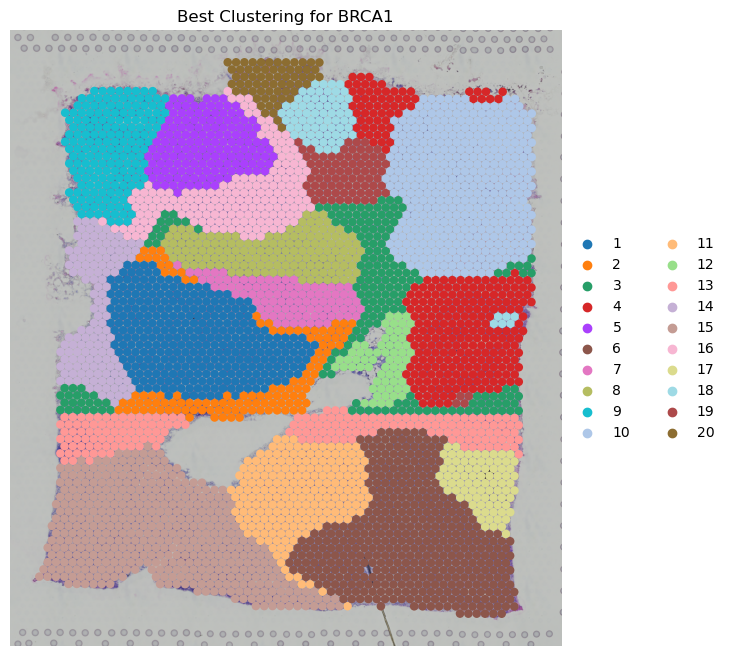

In [23]:

import matplotlib.pyplot as plt
from ViMST.utils import build_args

# 初始化其他参数
args = build_args()
args.hidden_dim, args.latent_dim = 512, 256
args.max_epoch = 500
args.top_genes = 3000
args.n_clusters = 20
args.lam = 1
args.feat_mask_rate = 0.2
args.img_mask_rate = 0.25
#最佳
args.k_cutoff = 8 
args.nps = 16 
args.edge_drop_rate = 0.5 
# 数据路径
data_root = Path("/home/Data/BRCA/")

section_id = ["BRCA1"] 
for tissue_name in section_id:
    count_file = tissue_name + "/spatial/filtered_feature_bc_matrix.h5"
    adata = sc.read_visium(data_root, count_file=count_file)
    # 读取文件并保留第三列
    truth_path = "/home/Data/BRCA/" + tissue_name + '/metadata.tsv'
    truth_labels = pd.read_csv(truth_path, sep='\t', header=0)
    truth_labels.index = adata.obs_names
    adata.obs['Ground Truth'] = truth_labels['fine_annot_type']

    # 检查adata.obs中是否有'merge_cell_type'列
    if 'Ground Truth' not in adata.obs:
        print(f"警告: 'Ground Truth' 不存在!")
        continue
    


    # 训练并计算ARI、NMI
    ARI, NMI, adata = train_one(args, adata, tissue_name)

    output_path = f"/home/Data/BRCA/Results/{tissue_name}_processed.h5ad"
    adata.write(output_path)


    # 绘制最佳配置下的聚类图
    fig, ax = plt.subplots(figsize=(16, 8))
    sc.pl.spatial(adata, color=['mclust'], show=False, spot_size=280, ax=ax)
    ax.set_title(f"Best Clustering for {tissue_name}")
    ax.axis('off')
    plt.show()


In [25]:
adata

AnnData object with n_obs × n_vars = 3798 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg', 'Spatial_Net', 'mclust_colors'
    obsm: 'spatial', 'feat', 'feat1', 'eval_pred', 'eval_recon'
    layers: 'count'

In [26]:
sc.tl.rank_genes_groups(adata, groupby='mclust', use_raw=False, layer='count', method='t-test')

In [27]:
de_genes = pd.DataFrame(adata.uns['rank_genes_groups']['names']).iloc[:10,:]
de_genes

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,PCSK1N,IFT122,MRPS30-DT,MGP,COX6C,LINC00645,SNCG,IL6ST,SLITRK6,ACKR1,C3,CCL14,CCND1,SH3BGRL,KAT6B,SNCG,CPB1,TIMP1,MUC1,KRT17
1,APOE,AC087379.2,PDE5A,DSP,FAM234B,MUC5B,WFDC2,TBC1D9,CRISP3,CHRDL1,TNXB,TNXB,MUC1,PYDC1,MGP,LYZ,LINC02224,CCDC80,KRT18,KRT5
2,LTB,IFI6,WFDC2,SERPINA3,CSTA,PVALB,EIF4EBP1,FARP1,IGFBP5,TTN,PTGDS,CHRDL1,S100A11,ATP8A2,HK2,HLA-DPA1,LYZ,BGN,GFRA1,KRT14
3,SFRP4,WASHC5,MRPS30,RPL26,SLC39A6,EXOC2,MCCD1,COX6C,S100A13,ADAM33,TRBC2,ACKR1,DEGS1,THBS4,BASP1,HLA-DQA1,NKG7,C1R,KRT8,HTRA3
4,COMP,HEBP1,RBM20,BACE2,SNCG,SLC30A8,H2AFJ,ERLIN2,CALML5,NR2F1,JAML,CLDN5,DEGS2,SHISA2,S100G,CCL5,JAK3,SFRP4,CCND1,MMP7
5,TRBC2,ITPR1,KCNE4,LDHA,LINC00052,COLEC12,RAB11FIP1,H2AFJ,S100A16,CCL14,TBC1D10C,CCL21,TUBA1B,H19,GPC3,MCCD1,CXCL9,PRELP,UQCRQ,BGN
6,ADAM28,PCED1B,AMFR,IGFBP5,HEBP1,ADORA2A,EEF1A2,RAB11FIP1,S100A14,LCN6,C7,EFEMP1,CRAT,COL2A1,KRT37,RARRES1,HLA-DPA1,C3,DEGS2,STRA6
7,COL14A1,AMIGO2,SYT1,RAB11FIP1,WFDC2,LINC02224,SLC7A5,WWP1,PSMA6,SFRP1,CCL19,MMRN1,MORF4L2,KRT7,PGC,CXCL9,NPY1R,FOS,TTLL12,S100A2
8,CCDC80,IFI27,AC090994.1,GAPDH,UGCG,AC037198.2,TSKU,LINC02224,KRT8,INMT,IGHG3,ADAM33,PSMB4,RMND1,DRAIC,APOE,ADA2,C1S,CXCL14,AEBP1
9,HCST,S100G,SNCG,RPL14,TBC1D9,FGFR4,RAMP1,BAMBI,H3F3A,ABCA8,LTB,OGN,GALNT6,CLEC3A,STC2,EIF4EBP1,TRAC,SFRP2,TCEAL4,TNN


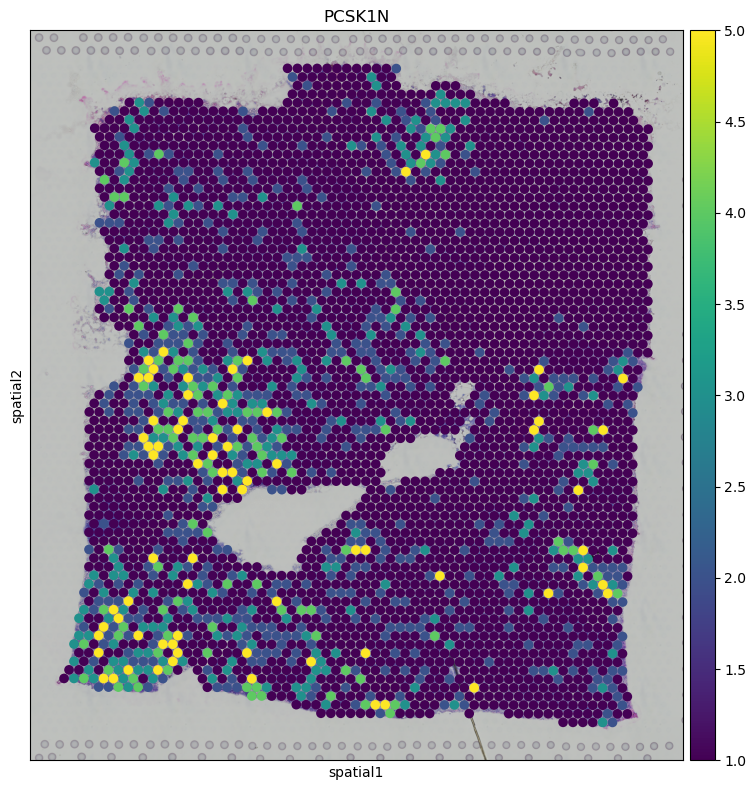

In [28]:
fig, axs = plt.subplots(figsize=(8, 8))

sc.pl.spatial(
    adata,
    img_key='hires',
    color=de_genes.iloc[0,0],
    layer='count',
    size=1.5,
    palette=sc.pl.palettes.default_102,
    legend_loc='right margin',
    vmin='p50',
    vmax='p99',
    show=False,
    ax=axs,
)

plt.tight_layout()

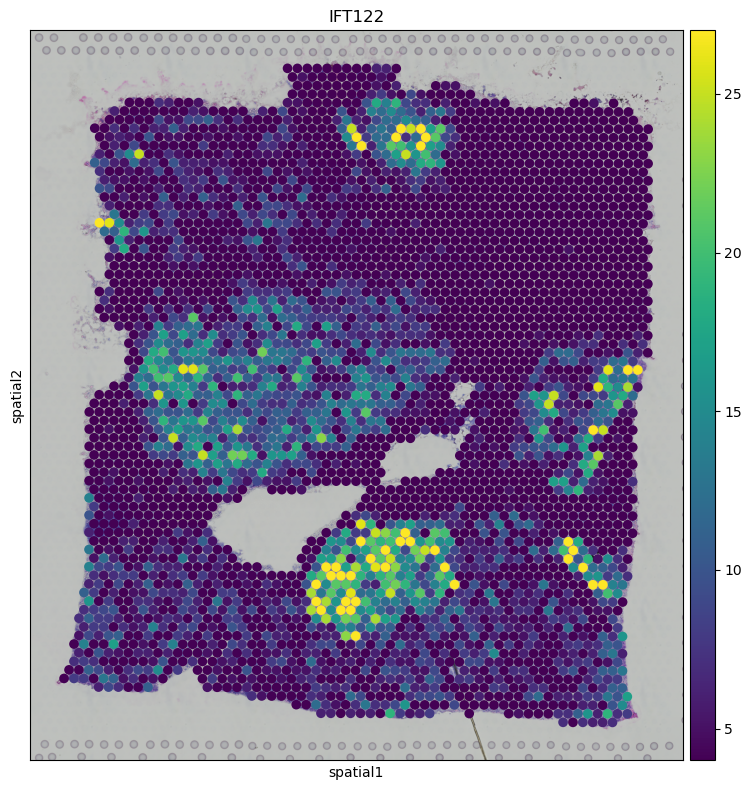

In [29]:
fig, axs = plt.subplots(figsize=(8, 8))

sc.pl.spatial(
    adata,
    img_key='hires',
    color=de_genes.iloc[0,1],
    layer='count',
    size=1.5,
    palette=sc.pl.palettes.default_102,
    legend_loc='right margin',
    vmin='p50',
    vmax='p99',
    show=False,
    ax=axs,
)

plt.tight_layout()

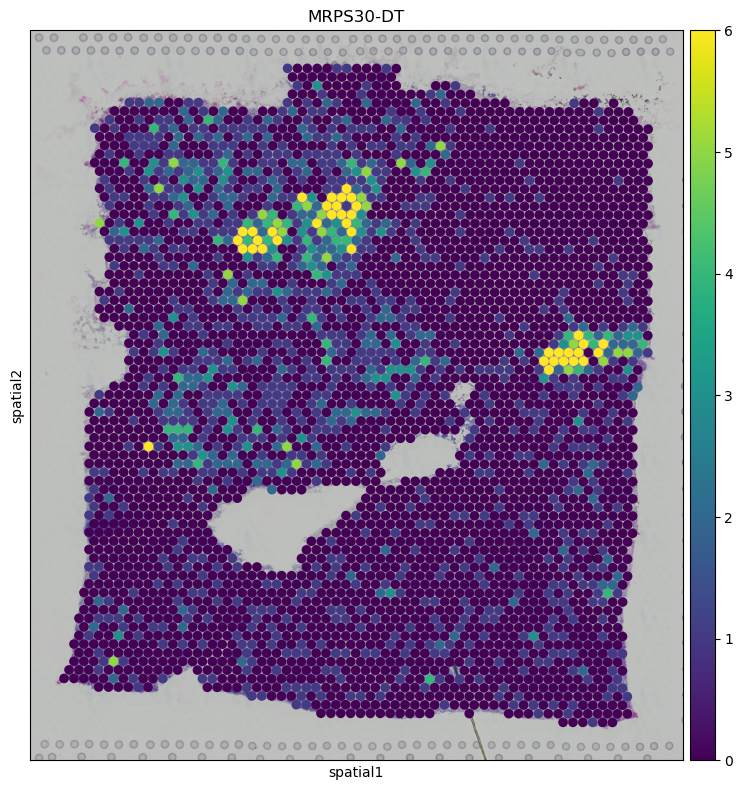

In [30]:
fig, axs = plt.subplots(figsize=(8, 8))

sc.pl.spatial(
    adata,
    img_key='hires',
    color=de_genes.iloc[0,2],
    layer='count',
    size=1.5,
    palette=sc.pl.palettes.default_102,
    legend_loc='right margin',
    vmin='p50',
    vmax='p99',
    show=False,
    ax=axs,
)

plt.tight_layout()

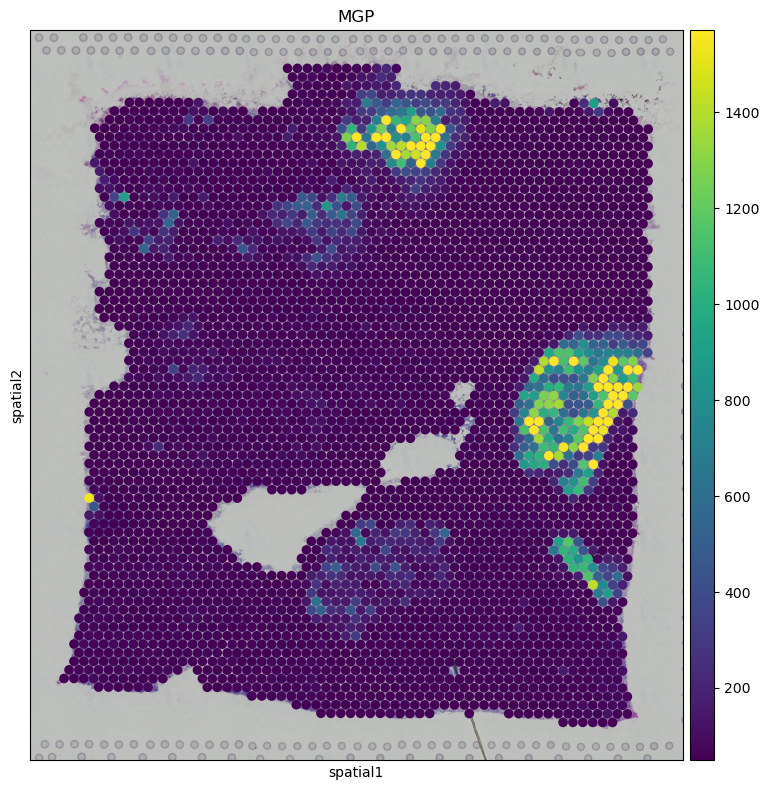

In [31]:
fig, axs = plt.subplots(figsize=(8, 8))

sc.pl.spatial(
    adata,
    img_key='hires',
    color=de_genes.iloc[0,3],
    layer='count',
    size=1.5,
    palette=sc.pl.palettes.default_102,
    legend_loc='right margin',
    vmin='p50',
    vmax='p99',
    show=False,
    ax=axs,
)

plt.tight_layout()